In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

In [ ]:
url = 'https://raw.githubusercontent.com/ManjuVijayakumar/ICTAK_DSA_Internship/refs/heads/main/edtech_data_scrape_final.csv'
data= pd.read_csv(url)
data.head()

,course_title,course_url,platform,language,duration,difficulty_level,rating_out_of_5
0,3-pillars-of-successful-marketing-segmentation...,https://www.futurelearn.com/career-advice,FutureLearn,English,4 weeks,Beginner,4.5
1,4-0-shades-of-digitalisation-for-the-chemical-...,https://www.futurelearn.com/career-advice/beco...,FutureLearn,English,8 weeks,Advanced,4.5
2,5 benefits of giving up alcohol,https://www.futurelearn.com/career-advice/beco...,FutureLearn,English,4 weeks,Beginner,4.5
3,5g-and-wireless-communication-for-beginners,https://www.futurelearn.com/career-advice/beco...,FutureLearn,English,4 weeks,Beginner,4.5
4,aat-level-1-award-in-bookkeeping,https://www.futurelearn.com/career-advice/beco...,FutureLearn,English,4 weeks,Beginner,4.5


In [ ]:
data.tail()

,course_title,course_url,platform,language,duration,difficulty_level,rating_out_of_5
5359,Covid Uncovered,https://www.coursera.org/learn/covid-uncovered,Coursera,English,9 hours,Beginner,4.7
5360,Covid Vaccine Ambassador,https://www.coursera.org/learn/covid-vaccine-a...,Coursera,English,9 hours,Beginner,4.7
5361,Covid Vaccine Ambassador Spanish,https://www.coursera.org/learn/covid-vaccine-a...,Coursera,English,9 hours,Beginner,4.7
5362,Covid19Clinicalupdate,https://www.coursera.org/learn/covid19clinical...,Coursera,English,9 hours,Beginner,4.7
5363,Cpanel Advanced Configure Secure Optimize,https://www.coursera.org/learn/cpanel-advanced...,Coursera,English,9 hours,Beginner,4.7


## **Exploratory Data Analysis**

In [ ]:
data.shape

(5364, 7)

In [ ]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5364 entries, 0 to 5363
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   course_title      5364 non-null   object 
 1   course_url        5364 non-null   object 
 2   platform          5364 non-null   object 
 3   language          5364 non-null   object 
 4   duration          4477 non-null   object 
 5   difficulty_level  4244 non-null   object 
 6   rating_out_of_5   4257 non-null   float64
dtypes: float64(1), object(6)
memory usage: 293.5+ KB


In [ ]:
# Missing values
data.isnull().sum()

,0
course_title,0
course_url,0
platform,0
language,0
duration,887
difficulty_level,1120
rating_out_of_5,1107


In [ ]:
# Statistic Summary
data.describe(include= 'all')

,course_title,course_url,platform,language,duration,difficulty_level,rating_out_of_5
count,5364,5364,5364,5364,4477,4244,4257.000000
unique,5193,5357,4,6,91,8,NaN
top,healthcare,https://www.open.edu/openlearn/education-devel...,FutureLearn,English,4 weeks,Beginner,NaN
freq,8,2,2601,5346,2314,3785,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,4.575335
std,NaN,NaN,NaN,NaN,NaN,NaN,0.152909
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,4.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,4.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,4.700000


### Handle missing data

In [ ]:
# Calculate percentage of missing values per columns
missing_percent= (data.isnull().sum() / len(data)) * 100

# Combine with Counts
missing_data= pd.DataFrame(
    {
        'Missing Values' : data.isnull().sum(),
        'Percentage (%)' : missing_percent
    }
).sort_values(by= 'Percentage (%)', ascending= False)

missing_data= missing_data[missing_data['Missing Values'] > 0]

print(missing_data)

                  Missing Values  Percentage (%)
difficulty_level            1120       20.879940
rating_out_of_5             1107       20.637584
duration                     887       16.536167


In [ ]:
# duration
data.duration.value_counts().head(10)

,count
duration,
4 weeks,2314
9 hours,1300
3 weeks,120
2 weeks,116
20 hours,47
10 hours,46
5 weeks,37
4 hours,34
6 weeks,28


In [ ]:
# Convert duration to numeric

import re
import numpy as np

def duration_to_hours(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower()
    num = re.findall(r"[\d\.]+", val)
    if not num:
        return np.nan
    num = float(num[0])

    if 'week' in val:
        return num * 10   # approx 10 hrs/week
    if 'hour' in val:
        return num
    return np.nan

data['duration_hours'] = data['duration'].apply(duration_to_hours)


In [ ]:
data.duration_hours.dtype

dtype('float64')

In [ ]:
# difficulty_level
data.difficulty_level.value_counts(dropna= False)

,count
difficulty_level,
Beginner,3785
NaN,1120
Intermediate,183
Introductory,135
Advanced,61
Open level,45
Level 1: Introductory,28
Level 3: Advanced,6
Level 2: Intermediate,1


In [ ]:
# Define a mapping dictionary
difficulty_map = {
    'Beginner': 'Beginner',
    'Introductory': 'Beginner',
    'Level 1: Introductory': 'Beginner',
    'Open level': 'Beginner',

    'Intermediate': 'Intermediate',
    'Level 2: Intermediate': 'Intermediate',

    'Advanced': 'Advanced',
    'Level 3: Advanced': 'Advanced'
}

data.difficulty_level= data.difficulty_level.map(difficulty_map)

data.difficulty_level.value_counts(dropna= False)

,count
difficulty_level,
Beginner,3993
NaN,1120
Intermediate,184
Advanced,67


In [ ]:
# Fill difficulty level with duration buckets
data['difficulty_level'] = data.groupby(
    pd.cut(data['duration_hours'], bins=[0, 10, 30, 60, 100, 200])
)['difficulty_level'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

In [ ]:
# Fill with median for fallback rows
data['duration_hours'].fillna(data['duration_hours'].median(), inplace=True)

In [ ]:
# rating_out_of_5 - target variable

df_model= data[data.rating_out_of_5.notna()].copy()
df_unrated= data[data.rating_out_of_5.isna()].copy()

In [ ]:
df_model.isnull().sum()

,0
course_title,0
course_url,0
platform,0
language,0
duration,1
difficulty_level,1
rating_out_of_5,0
duration_hours,0


In [ ]:
df_model[df_model[['duration', 'difficulty_level']].isnull().any(axis=1)]

,course_title,course_url,platform,language,duration,difficulty_level,rating_out_of_5,duration_hours
3596,Analysis For Business Systems,https://www.coursera.org/learn/analysis-for-bu...,Coursera,English,NaN,NaN,4.8,40.0


In [ ]:
# Drop
df_model= df_model.dropna(subset= ['duration', 'difficulty_level'])
df_model.isnull().sum()

,0
course_title,0
course_url,0
platform,0
language,0
duration,0
difficulty_level,0
rating_out_of_5,0
duration_hours,0


In [ ]:
df_unrated.isnull().sum()

,0
course_title,0
course_url,0
platform,0
language,0
duration,886
difficulty_level,891
rating_out_of_5,1107
duration_hours,0


In [ ]:
df_unrated[df_unrated[['duration', 'difficulty_level']].isnull().any(axis=1)]

,course_title,course_url,platform,language,duration,difficulty_level,rating_out_of_5,duration_hours
2640,the-university-of-edinburgh-critical-care-msc,https://www.open.edu/openlearn/money-business/...,OpenLearn,English,NaN,NaN,NaN,40.0
2641,the-university-of-edinburgh-data-and-decision-...,https://www.open.edu/openlearn/intrapreneurshi...,OpenLearn,English,NaN,NaN,NaN,40.0
2642,the-university-of-edinburgh-data-science-for-h...,https://www.open.edu/openlearn/health-sports-p...,OpenLearn,English,NaN,NaN,NaN,40.0
2643,the-university-of-edinburgh-global-health-and-...,https://www.open.edu/openlearn/employability-hub,OpenLearn,English,NaN,NaN,NaN,40.0
2644,the-university-of-edinburgh-high-performance-c...,https://www.open.edu/openlearn/midlife-mot,OpenLearn,English,NaN,NaN,NaN,40.0
...,...,...,...,...,...,...,...,...
3859,Assessing Cultural Climate,https://www.coursera.org/learn/assessing-cultu...,Coursera,English,NaN,NaN,NaN,40.0
3860,Assessingconflict,https://www.coursera.org/learn/assessingconflict,Coursera,English,NaN,NaN,NaN,40.0
3861,Assessment Higher Education,https://www.coursera.org/learn/assessment-high...,Coursera,English,NaN,NaN,NaN,40.0
3862,Assessment Interviewing And Onboarding,https://www.coursera.org/learn/assessment-inte...,Coursera,English,NaN,NaN,NaN,40.0


In [ ]:
# Drop duration feature

df_model= df_model.drop(columns= ['duration'])
df_unrated= df_unrated.drop(columns= ['duration'])

In [ ]:
# difficulty level

df_unrated['difficulty_level'] = df_unrated.groupby(
    pd.cut(df_unrated['duration_hours'], bins=[0, 10, 30, 60, 100, 200])
)['difficulty_level'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

df_unrated['difficulty_level'].fillna(
    df_model['difficulty_level'].mode()[0],
    inplace=True
)

In [ ]:
df_unrated[['duration_hours', 'difficulty_level']].isnull().sum()

,0
duration_hours,0
difficulty_level,0


In [ ]:
assert df_model.isnull().sum().sum() == 0
# assert df_unrated.isnull().sum().sum() == 0

*   Performed an initial missing value audit to quantify null percentages across features
*   Identified rating_out_of_5 as target variable (success indicator)
* Dataset was split into
      Rated courses (for modeling)
      Unrated courses (used for prediction)
* Standardized difficulty level as Beginner, Intermediate and Advanced
* Converted duration to duration_hours
* Imputed missing difficulty_level values using duration-based grouping, leveraging the observed relationship between course length and difficulty
* Imputed missing duration_hours values using median values grouped by difficulty_level, with a global median fallback for edge cases.
* Conducted post-imputation validation



### Check for duplicates

In [ ]:
df_model.duplicated().sum()

np.int64(0)

In [ ]:
df_unrated.duplicated().sum()

np.int64(0)

* No duplicate values present

### Datatype Validation

In [ ]:
df_model.dtypes

,0
course_title,object
course_url,object
platform,object
language,object
difficulty_level,object
rating_out_of_5,float64
duration_hours,float64


In [ ]:
df_unrated.dtypes

,0
course_title,object
course_url,object
platform,object
language,object
difficulty_level,object
rating_out_of_5,float64
duration_hours,float64


### Category Cardinality Check

In [ ]:
df_model.nunique().sort_values(ascending=False)

,0
course_url,4256
course_title,4091
duration_hours,23
rating_out_of_5,19
language,4
platform,3
difficulty_level,3


In [ ]:
df_model.platform.value_counts()

,count
platform,
FutureLearn,2601
Coursera,1589
OpenLearn,66


### Outlier Detection

In [ ]:
df_model[['duration_hours', 'rating_out_of_5']].describe()

,duration_hours,rating_out_of_5
count,4256.000000,4256.000000
mean,28.073543,4.575282
std,15.624952,0.152888
min,1.000000,0.000000
25%,9.000000,4.500000
50%,40.000000,4.500000
75%,40.000000,4.700000
max,80.000000,5.000000


In [ ]:
df_unrated[['duration_hours', 'rating_out_of_5']].describe()

,duration_hours,rating_out_of_5
count,1107.000000,0.0
mean,37.261066,NaN
std,12.467156,NaN
min,1.000000,NaN
25%,40.000000,NaN
50%,40.000000,NaN
75%,40.000000,NaN
max,127.000000,NaN


In [ ]:
# Range and Validity Checks
(df_model['rating_out_of_5'] < 1).sum()
(df_model['rating_out_of_5'] > 5).sum()
(df_model['duration_hours'] <= 0).sum()
(df_unrated['duration_hours'] <= 0).sum()

np.int64(0)

### Feature redundancy check

In [ ]:
df_model.sample(4)

,course_title,course_url,platform,language,difficulty_level,rating_out_of_5,duration_hours
3893,Audio Digital Pure Data,https://www.coursera.org/learn/audio-digital-p...,Coursera,English,Intermediate,4.8,5.0
1983,natural-products-harnessing-nature-s-resources...,https://www.futurelearn.com/courses/transporti...,FutureLearn,English,Beginner,4.5,40.0
982,enterprise-risk-management,https://www.futurelearn.com/courses/hadrians-wall,FutureLearn,English,Beginner,4.5,40.0
4117,Azure Network Troubleshooting And Governance,https://www.coursera.org/learn/azure-network-t...,Coursera,English,Beginner,4.7,9.0


*   course_title
*   course_url
* language



### Feature Engineering

In [ ]:
# duration_bucket
df_model['duration_bucket'] = pd.cut(
    df_model['duration_hours'],
    bins=[0, 10, 30, 60, 100, 200],
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
)

#success_flag
df_model['success_flag'] = (df_model['rating_out_of_5'] >= 4.0).astype(int)

### Visualization

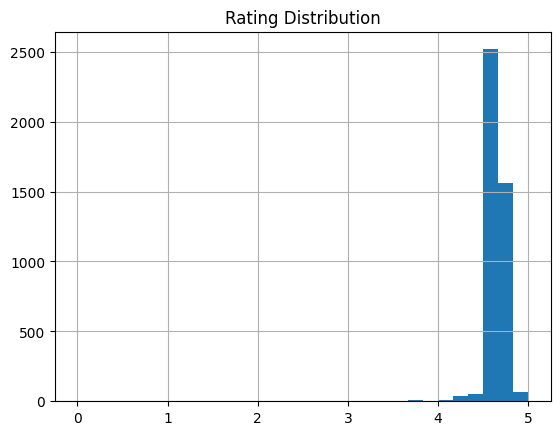

In [ ]:
# Target variable
df_model.rating_out_of_5.hist(bins = 30)
plt.title('Rating Distribution')
plt.show()

* Low rated courses are rare
* Majority of ratings fall between 4 - 5

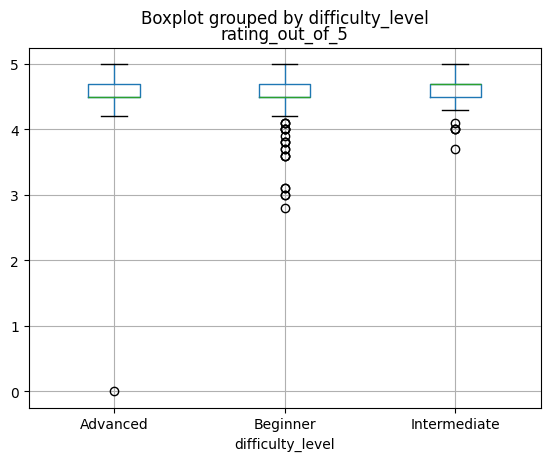

In [ ]:
# Rating density by Difficulty level
df_model.boxplot(column= 'rating_out_of_5', by= 'difficulty_level')
# plt.title('Rating density by Difficulty level')
plt.show()

*   Beginner courses get more rating

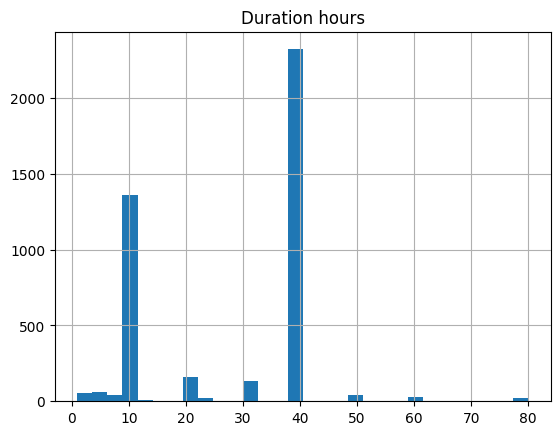

In [ ]:
df_model['duration_hours'].hist(bins=30)
plt.title('Duration hours')
plt.show()

* 40 hours classes are more dominant

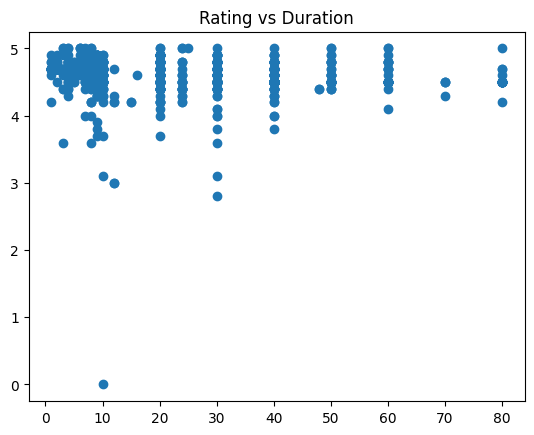

In [ ]:
# Rating vs Duration

plt.scatter(df_model.duration_hours, df_model.rating_out_of_5)
plt.title('Rating vs Duration')
plt.show()

* Both short and long duration courses have higher ratings
* Shorter duration courses have more number of ratings which may indicate that students prefer shorter duration courses
* There is no specific pattern

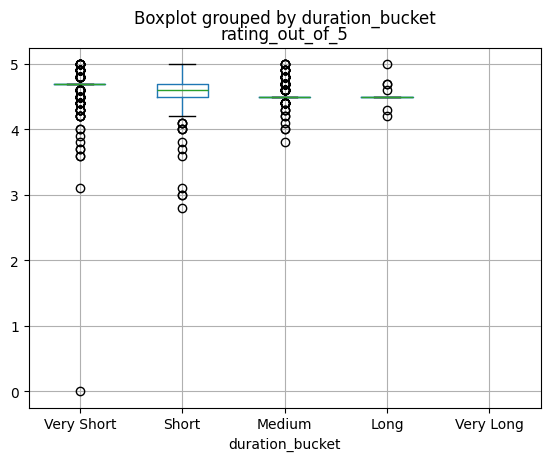

In [ ]:
# Rating by Duration Buckets
df_model.boxplot(column='rating_out_of_5', by='duration_bucket')
plt.show()

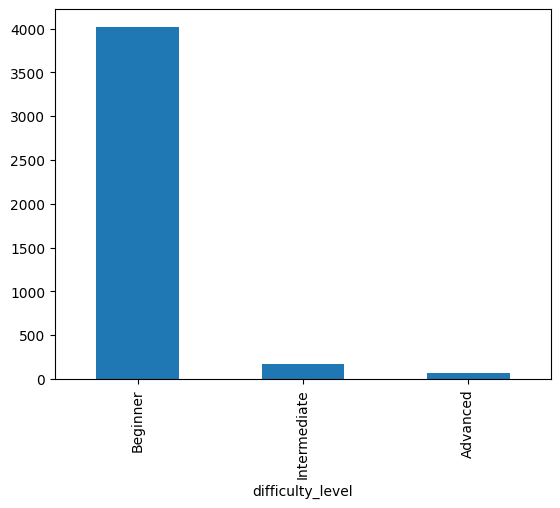

In [ ]:
df_model.difficulty_level.value_counts().plot(kind= 'bar')
plt.show()

* There are more Beginner level courses

<Axes: xlabel='difficulty_level'>

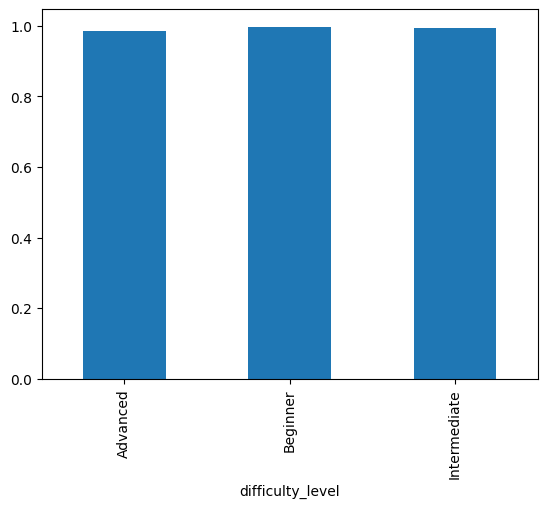

In [ ]:
df_model.groupby('difficulty_level')['success_flag'].mean().plot(kind='bar')

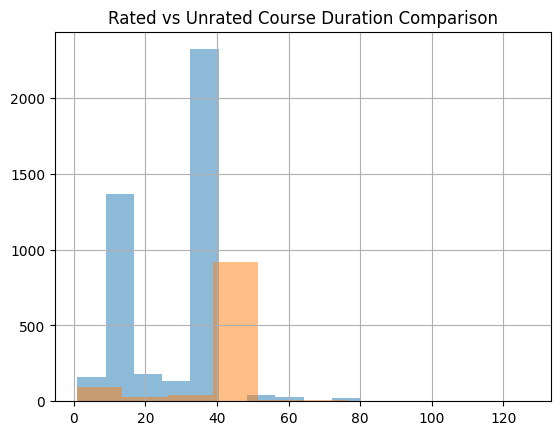

In [ ]:
# Rated vs Unrated Course Duration Comparison
plt.title('Rated vs Unrated Course Duration Comparison')
df_model['duration_hours'].hist(alpha=0.5)
df_unrated['duration_hours'].hist(alpha=0.5)
plt.show()

*   Unrated courses are not structurally different



### Lightweight textual features from course title

In [ ]:
# Title length
# Clear titles - higher engagement
# Overly long titles - diluted focus

df_model['title_word_count'] = df_model['course_title'].str.split().str.len()
df_model['title_char_count'] = df_model['course_title'].str.len()

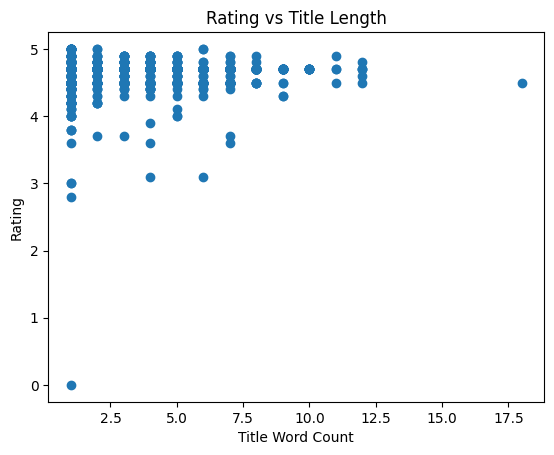

In [ ]:
plt.figure()
plt.scatter(df_model['title_word_count'], df_model['rating_out_of_5'])
plt.xlabel('Title Word Count')
plt.ylabel('Rating')
plt.title('Rating vs Title Length')
plt.show()

*   Most courses cluster between title length 2-8 words
*   Ratings are mostly high (4.0-5.0) across almost all title lengths



In [ ]:
# Correlation between title word count and rating
df_model[['title_word_count', 'rating_out_of_5']].corr()

,title_word_count,rating_out_of_5
title_word_count,1.000000,0.384301
rating_out_of_5,0.384301,1.000000


In [ ]:
df_model[['title_char_count', 'rating_out_of_5']].corr()

,title_char_count,rating_out_of_5
title_char_count,1.00000,-0.05435
rating_out_of_5,-0.05435,1.00000


*   As title word count increases, ratings tend to slightly higher on average

In [ ]:
# title_length_bucket
df_model['title_length_bucket'] = pd.cut(
    df_model['title_word_count'],
    bins=[0, 3, 6, 10, 20],
    labels=['Very Short', 'Short', 'Medium', 'Long']
)

In [ ]:
df_model.sample(4)

,course_title,course_url,platform,language,difficulty_level,rating_out_of_5,duration_hours,duration_bucket,success_flag,title_word_count,title_char_count,title_length_bucket
471,climate-adaptation-governance,https://www.futurelearn.com/courses/communicat...,FutureLearn,English,Beginner,4.5,40.0,Medium,1,1,29,Very Short
4013,Aws Database Dva C02,https://www.coursera.org/learn/aws-database-dv...,Coursera,English,Beginner,4.7,9.0,Very Short,1,4,20,Short
4103,Azure Compute And Application Architecture Sol...,https://www.coursera.org/learn/azure-compute-a...,Coursera,English,Beginner,4.7,9.0,Very Short,1,6,52,Short
2637,the-universal-declaration-of-human-rights,https://www.open.edu/openlearn/money-business/...,OpenLearn,English,Beginner,4.2,8.0,Very Short,1,1,41,Very Short


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4256 entries, 0 to 5363
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   course_title         4256 non-null   object  
 1   course_url           4256 non-null   object  
 2   platform             4256 non-null   object  
 3   language             4256 non-null   object  
 4   difficulty_level     4256 non-null   object  
 5   rating_out_of_5      4256 non-null   float64 
 6   duration_hours       4256 non-null   float64 
 7   duration_bucket      4256 non-null   category
 8   success_flag         4256 non-null   int64   
 9   title_word_count     4256 non-null   int64   
 10  title_char_count     4256 non-null   int64   
 11  title_length_bucket  4256 non-null   category
dtypes: category(2), float64(2), int64(3), object(5)
memory usage: 374.5+ KB


## **Model Building** - Target:- rating_out_of_5

Feature list

Target - rating_out_of_5

For Primary Regression model
*   difficulty_level
*   duration_hours
* title_word_count

For tree-based models
* difficulty_level
* duration_bucket
* title_length_bucket



In [ ]:
# Prepare modeling dataframe

features = [ 'difficulty_level', 'duration_hours', 'title_word_count']

df_model_final= df_model[features + ['rating_out_of_5']]
df_model_final.columns

Index(['difficulty_level', 'duration_hours', 'title_word_count',
       'rating_out_of_5'],
      dtype='object')

In [ ]:
# Encode categorical feature
df_model_final.difficulty_level.value_counts()

,count
difficulty_level,
Beginner,4020
Intermediate,170
Advanced,66


In [ ]:
# from sklearn.preprocessing import OneHotEncoder

# ohe = OneHotEncoder(sparse_output=False, drop='first')

# # Fit and transform
# df_model_final.difficulty_level = df_model_final.difficulty_level.str.strip()
# diff_encoded= ohe.fit_transform(df_model_final[['difficulty_level']])
# diff_cols = [f"diff_{cat}" for cat in ohe.categories_[0][1:]]  # skip first category
# diff_cols
# difficulty_df = pd.DataFrame(diff_encoded, columns=diff_cols, index=df_model_final.index)
# df_model_final = pd.concat([df_model_final.drop(columns=['difficulty_level']), difficulty_df], axis=1)

In [ ]:
X= df_model_final.drop('rating_out_of_5', axis= 1)
y= df_model_final.rating_out_of_5

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_feats= ['duration_hours', 'title_word_count']
cat_feats= ['difficulty_level']

preprocessor= ColumnTransformer (
    transformers = [
        ('num', StandardScaler(), num_feats),
        ('cat', OneHotEncoder(drop= 'first'), cat_feats)
    ]
)

### Build pipeline

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

models= {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=0.05)
}

pipelines = {
    name : Pipeline(steps= [
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}

### Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 29)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3404, 3) (852, 3) (3404,) (852,)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    rmse = mean_squared_error(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train_R2,Test_R2,RMSE
0,Linear Regression,0.356240,0.132721,0.037979
1,Ridge Regression,0.356240,0.132912,0.037970
2,Lasso Regression,0.211978,0.082880,0.040161


Linear regression models exhibited limited explanatory power, indicating that the relationship between course attributes and ratings is not strictly linear. While prediction errors remained low in magnitude, the low test R² suggests the presence of non-linear interactions and unobserved influencing factors.

In [ ]:

numeric_features = ['duration_hours', 'title_word_count']
categorical_features = ['difficulty_level']

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
# Build pipelines
from sklearn.pipeline import Pipeline

tree_models = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=20,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

tree_pipelines = {
    name: Pipeline(steps=[
        ('preprocessing', preprocessor_tree),
        ('model', model)
    ])
    for name, model in tree_models.items()
}

In [ ]:
results = []

for name, pipeline in tree_pipelines.items():
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    results.append({
        'Model': name,
        'Train_R2': r2_score(y_train, y_train_pred),
        'Test_R2': r2_score(y_test, y_test_pred),
        'RMSE': mean_squared_error(y_test, y_test_pred)
    })

results_tree_df = pd.DataFrame(results)
results_tree_df

,Model,Train_R2,Test_R2,RMSE
0,Decision Tree,0.432978,0.161022,0.036739
1,Random Forest,0.452321,0.190580,0.035445
2,Gradient Boosting,0.526955,0.152005,0.037134


Tree-based models exhibited higher training performance compared to testing performance, indicating mild overfitting. However, ensemble methods such as Random Forest demonstrated improved generalization over single trees, suggesting that non-linear interactions exist but are constrained by limited feature informativeness and target variability.



## **Model Building** - Target:- success_flag

In [ ]:
df_model.sample(3)
df_model.success_flag.value_counts()

,count
success_flag,
1,4240
0,16


In [ ]:
# Redefining success_flag since Ratings are skewed high
# Distinguishes 'excellent' from 'average-good'

df_model['success_flag'] = (df_model['rating_out_of_5'] >= 4.5).astype(int)

In [ ]:
df_model.success_flag.value_counts()

,count
success_flag,
1,4145
0,111


Due to strong rating concentration at higher values and minimal variance below 4.2, the problem was reframed as a **3-class success prediction** task. Thresholds were derived from natural data clusters to ensure class balance and interpretability.

Low      : rating < 4.5 <br>
Medium   : 4.5 ≤ rating < 4.7 <br>
High     : rating ≥ 4.7

In [ ]:
def success_tier(rating):
    if rating >= 4.7:
        return 'High'
    elif (rating >= 4.5 and rating < 4.7):
        return 'Medium'
    else:
        return 'Low'

df_model['success_tier'] = df_model['rating_out_of_5'].apply(success_tier)

df_model.success_tier.value_counts(normalize=True)

,proportion
success_tier,
Medium,0.591635
High,0.382284
Low,0.026081


In [ ]:
# df_model.rating_out_of_5.value_counts()
df_model.columns

Index(['course_title', 'course_url', 'platform', 'language',
       'difficulty_level', 'rating_out_of_5', 'duration_hours',
       'duration_bucket', 'success_flag', 'title_word_count',
       'title_char_count', 'title_length_bucket', 'success_tier'],
      dtype='object')

Input Features

* difficulty_level (categorical)
* duration_hours (numeric)
* duration_bucket (ordinal / categorical)
* title_word_count
* title_length_bucket

Target
* success_tier

In [ ]:
df_model[['difficulty_level','duration_hours','duration_bucket','title_word_count','title_length_bucket']].sample(3)

,difficulty_level,duration_hours,duration_bucket,title_word_count,title_length_bucket
1661,Beginner,40.0,Medium,1,Very Short
358,Beginner,40.0,Medium,3,Very Short
2616,Advanced,10.0,Very Short,1,Very Short


In [ ]:
# Ensure correct ordering of success_tier

df_copy = df_model.copy()

tier_order = ["Low", "Medium", "High"]

df_copy["success_tier"] = pd.Categorical(
    df_copy["success_tier"],
    categories=tier_order,
    ordered=True
)

# Top 10 courses
top_10_courses = (
    df_copy
    .sort_values(
        by=["success_tier", "rating_out_of_5"],
        ascending=[False, False]
    )
    .head(10)
)

top_10_titles = top_10_courses["course_title"].tolist()

In [ ]:
top_10_titles

['ai-engineer-with-microsoft-azure',
 'antimicrobial-stewardship-for-africa',
 'Aquatic mammals',
 'become-successful-baker-bbc-good-food',
 'beginning-your-digital-marketing-journey',
 'brand-personality-jonathan-wilson',
 'the-highland-clans',
 'the-networks-connecting-people',
 'the-nhs-explained',
 'the-role-of-semiconductor-innovation-in-shaping-geopolitical-dynamics']

In [ ]:
def normalize_course_title(title):
    return title.replace("-", " ").title()

clean_titles = [normalize_course_title(t) for t in top_10_titles]
clean_titles

['Ai Engineer With Microsoft Azure',
 'Antimicrobial Stewardship For Africa',
 'Aquatic Mammals',
 'Become Successful Baker Bbc Good Food',
 'Beginning Your Digital Marketing Journey',
 'Brand Personality Jonathan Wilson',
 'The Highland Clans',
 'The Networks Connecting People',
 'The Nhs Explained',
 'The Role Of Semiconductor Innovation In Shaping Geopolitical Dynamics']

### Build a class-weighted multinomial model

In [ ]:
from sklearn.linear_model import LogisticRegression

X= df_model[['difficulty_level','duration_hours','duration_bucket','title_word_count','title_length_bucket']]
y= df_model.success_tier

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 29)

categorical_features = ['difficulty_level', 'duration_bucket', 'title_length_bucket']

numeric_features= ['duration_hours', 'title_word_count']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        class_weight='balanced',
        max_iter=2000
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['difficulty_level',
                                                   'duration_bucket',
                                                   'title_length_bucket']),
                                                 ('num', StandardScaler(),
                                                  ['duration_hours',
                                                   'title_word_count'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    multi_class='multinomial'))])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred= model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.95      0.85      0.90       326
         Low       0.13      0.50      0.21        22
      Medium       0.96      0.90      0.93       504

    accuracy                           0.87       852
   macro avg       0.68      0.75      0.68       852
weighted avg       0.93      0.87      0.90       852

[[277  36  13]
 [  4  11   7]
 [ 11  38 455]]


Class-wise interpretation

HIGH: <br>
*   When the model **predicts High, it is correct 95% of the time.**
*   It **captures 85% of truly high-success courses**.

MEDIUM: <br>
* **Extremely stable**
* Very little confusion with HIGH
* Acts as a solid middle buffer.

LOW: <br>
* The model **detects half of all low courses**
* It intentionally over predicts Low (low precision) <br>

Confusion Matrix: <br>
* Some High ↔ Medium confusion → expected (ratings are close)
* Low is never ignored
* No catastrophic misclassification pattern

In [ ]:
import pandas as pd

feature_names = (
    model.named_steps['preprocess']
    .get_feature_names_out()
)

coefficients = model.named_steps['clf'].coef_

coef_df = pd.DataFrame(
    coefficients.T,
    index=feature_names,
    columns=model.named_steps['clf'].classes_
)

coef_df.sort_values(by='High', ascending=False).head(10)

,High,Low,Medium
cat__duration_bucket_Very Short,2.897414,0.753428,-3.650842
num__duration_hours,0.839798,0.258288,-1.098086
num__title_word_count,0.571695,-0.596612,0.024916
cat__title_length_bucket_Very Short,0.463044,-0.590355,0.127311
cat__duration_bucket_Short,0.446584,1.102247,-1.548831
cat__title_length_bucket_Short,0.275713,0.167481,-0.443194
cat__difficulty_level_Beginner,0.122681,-0.484467,0.361786
cat__difficulty_level_Intermediate,0.031616,0.523321,-0.554937
cat__title_length_bucket_Long,-0.317364,-0.085604,0.402968
cat__difficulty_level_Advanced,-0.647654,0.352849,0.294805


**Macro F1 = 0.68**

True performance indicator.

For a dataset with:

> 2.6% minority class
> Subjective ratings
> Compressed target

👉 Macro F1 ≈ 0.65–0.70 is very good

In [ ]:
# y_pred

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model= Pipeline(steps= [
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators= 300,
        max_depth= None,
        min_samples_leaf= 5,
        class_weight= 'balanced',
        random_state= 29,
        n_jobs= -1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['difficulty_level',
                                                   'duration_bucket',
                                                   'title_length_bucket']),
                                                 ('num', StandardScaler(),
                                                  ['duration_hours',
                                                   'title_word_count'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=29))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       0.97      0.83      0.90       326
         Low       0.15      0.68      0.24        22
      Medium       0.97      0.90      0.94       504

    accuracy                           0.87       852
   macro avg       0.70      0.81      0.69       852
weighted avg       0.95      0.87      0.90       852

[[272  45   9]
 [  2  15   5]
 [  7  42 455]]


In [ ]:
# y_pred_rf

In [ ]:
results_compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Macro_F1': [0.68, 0.69],   # fill after computing
    'Accuracy': [0.87, 0.87]
})

results_compare

,Model,Macro_F1,Accuracy
0,Logistic Regression,0.68,0.87
1,Random Forest,0.69,0.87


Class-wise interpretation

HIGH:

Very reliable predictions <br> Slight recall drop vs LR -- acceptable <br> Excellent at identifying top courses
MEDIUM:

Extremely stable <br> Almost identical to LR <br> Strong anchor class

LOW:

Detects 68% of low criteria courses <br>
Better minority sensitivity than LR <br>
Low precision - expected with rare class

Confusion Matrix:

Some High ↔ Medium confusion → expected (ratings are close) <br>
Low class rarely missed


In [ ]:
# Get feature names after preprocessing
feature_names = (
    rf_model
    .named_steps['preprocess']
    .get_feature_names_out()
)

# Get feature importances
importances = rf_model.named_steps['clf'].feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

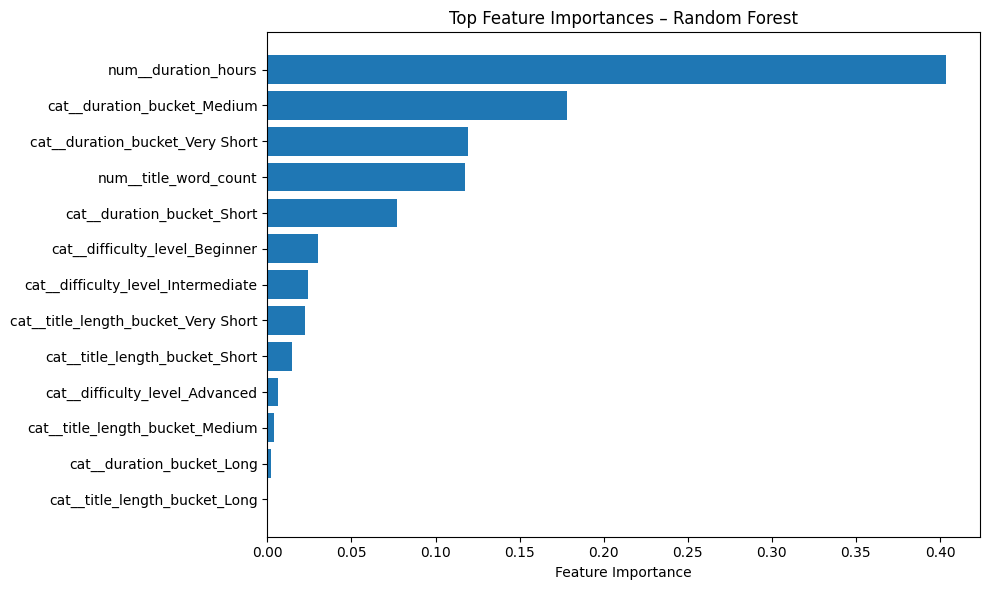

In [ ]:
# Plot top features
top_n = 15

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.head(top_n)['feature'][::-1],
    importance_df.head(top_n)['importance'][::-1]
)
plt.xlabel('Feature Importance')
plt.title('Top Feature Importances – Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
importance_df['base_feature'] = (
    importance_df['feature']
    .str.replace('cat__', '')
    .str.replace('num__', '')
    .str.split('_')
    .str[0]
)

grouped_importance = (
    importance_df
    .groupby('base_feature')['importance']
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

,importance
base_feature,
duration,0.780680
title,0.158884
difficulty,0.060436


* Course Duration is the dominant predictor of success
* Course title have a moderate influence (Contribute ~16% of importance)
* Difficulty level has comparatively smaller impact

## **Test model** (lasso)

In [ ]:
df_model_final.columns

NameError: name 'df_model_final' is not defined

In [ ]:
# Lasso as final model
# Retrain Lasso
features = [ 'difficulty_level', 'duration_hours', 'title_word_count']
df_model_final= df_model[features + ['rating_out_of_5']]

X= df_model_final.drop('rating_out_of_5', axis= 1)
y= df_model_final.rating_out_of_5

categorical_features = ["difficulty_level"]
numerical_features = ["duration_hours", "title_word_count"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.01))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 29)

lasso_pipeline.fit(X_train, y_train)

train_score = lasso_pipeline.score(X_train, y_train)
test_score = lasso_pipeline.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)


NameError: name 'df_model' is not defined

In [ ]:
# Save the trained model

import joblib

joblib.dump(lasso_pipeline, "/content/lasso_course_success_model.pkl")

In [ ]:
!ls /content

In [ ]:
import joblib
import pandas as pd

model = joblib.load("/content/lasso_course_success_model.pkl")

def predict_course_success(course_dict):

    input_df = pd.DataFrame([course_dict])
    success_score = model.predict(input_df)[0]

    if success_score >= 0.7:
        category = "High"
    elif success_score >= 0.4:
        category = "Medium"
    else:
        category = "Low"

    return success_score, category

In [ ]:
course = {
    "difficulty_level": "Intermediate",
    "duration_hours": 3,
    "title_word_count": 10
}

score, category = predict_course_success(course)

print("Score:", round(score, 2))
print("Category:", category)


In [ ]:
def genai_course_advisor(course, score, category):
    """
    Mock GenAI advisor (rule-based)
    """

    advice = []

    if category == "Low":
        advice.append("Predicted success is low. Consider improving course structure.")

    if course["difficulty_level"] == "Beginner" and course["duration_hours"] > 30:
        advice.append("Beginner courses perform better when duration is under 30 hours.")

    if course["title_word_count"] < 8000:
        advice.append("Consider adding more detailed explanations to improve engagement.")

    return " ".join(advice)

In [ ]:
# Test GenAI mock alone
course = {
    "difficulty_level": "Beginner",
    "duration_hours": 40,
    "title_word_count": 12000
}

mock_advice = genai_course_advisor(course, 0.35, "Low")
print(mock_advice)

In [ ]:
# Combine prediction + GenAI (end-to-end)
course = {
    "difficulty_level": "Beginner",
    "duration_hours": 40,
    "title_word_count": 12000
}

score, category = predict_course_success(course)
advice = genai_course_advisor(course, score, category)

print("Predicted Score:", round(score, 2))
print("Category:", category)
print("AI Recommendations:", advice)

In [ ]:
import sklearn
sklearn.__version__

## **Final model** RandomForestClassifier

In [ ]:
import pickle

with open("rf_course_success_model.pkl", "wb") as f:
  pickle.dump(rf_model, f)